# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [2]:
!pip install plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.9 MB 2.1 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.9 MB 2.3 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.9 MB 2.4 MB/s eta 0:00:04
   ------------ --------------------------- 3.1/9.9 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.9 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.9 MB 2.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 3.1 MB/s eta 0:00:02
   ----------------------------- ---------- 7.3/9.9 MB 3.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 3.4 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [4]:
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})

Draw a dispersion diagram (scatter plot) for the data.

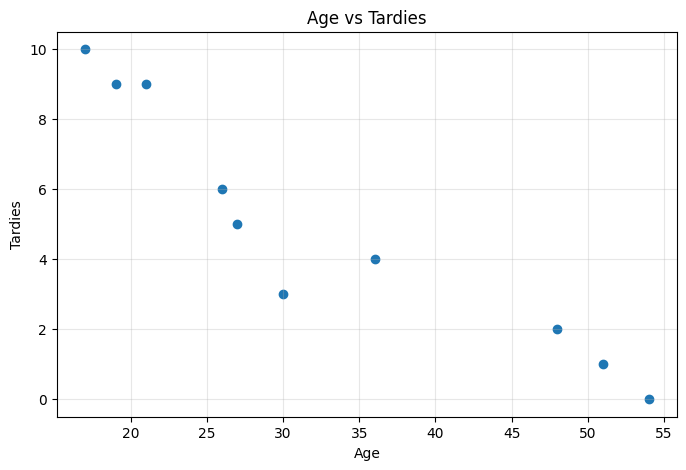

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(student_data['Age'], student_data['Tardies'])
plt.xlabel('Age')
plt.ylabel('Tardies')
plt.title('Age vs Tardies')
plt.grid(alpha=0.3)
plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

The graph shows clear linear relationship between age and number of tardies. Based on this specific sample, we could say that there is an inverse relationship between these 2 variables: the higher the age, the less is the number of tardies.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [10]:
covariance = student_data['Age'].cov(student_data['Tardies'])
print(f"Covariance: {covariance}")

correlation = student_data['Age'].corr(student_data['Tardies'])
print(f"Correlation: {correlation}")

from scipy.stats import pearsonr

# Returns correlation coefficient AND p-value
corr, p_value = pearsonr(student_data['Age'], student_data['Tardies'])
print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.6f}")

Covariance: -45.56666666666666
Correlation: -0.9391626886887122
Correlation: -0.939
P-value: 0.000056


In [13]:
type(student_data)

pandas.core.frame.DataFrame

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Convert a pandas Series to 2-d dataframe
X = student_data['Age'].to_frame()  

# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, student_data['Tardies'], test_size=0.4, random_state=42
)

# Step 2: Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 3: Make predictions
y_pred = model.predict(X_test)

# Step 4: Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE on test set: {rmse:.3f}")
print(f"R² score: {r2:.3f}")

# The outcome variable is 'Tardies', since we want to predict the number of late arrivals based on age.
# For 2 continuous variables I am using linear regrassion.

RMSE on test set: 3.407
R² score: 0.260


Plot your regression model on your scatter plot.

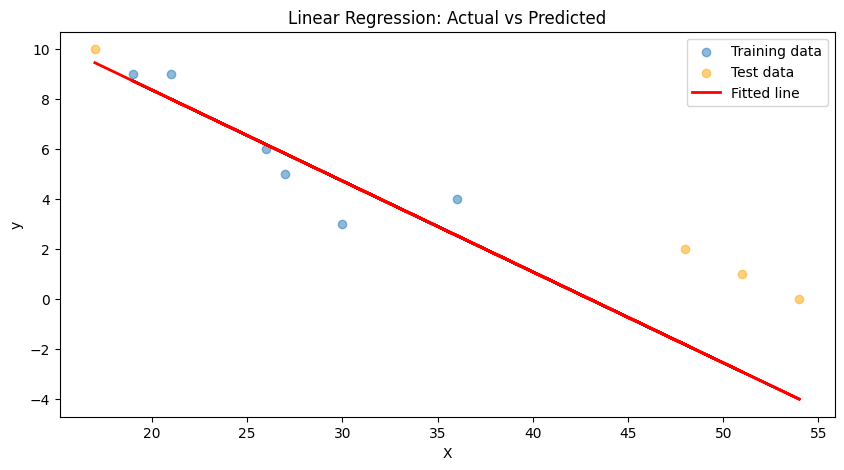

In [20]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, alpha=0.5, label='Training data')
plt.scatter(X_test, y_test, alpha=0.5, color='orange', label='Test data')
plt.plot(X, model.predict(X), 'r-', linewidth=2, label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

## Model Results with test_size=0.4

**Metrics:**
- RMSE: 3.407
- R²: 0.260

**Interpretation:**
- Model explains 26% of variance in Tardies based on Age alone
- Much better than previous negative R² (which resulted from too few test samples for test), which I received when I set the test size to 0.25
- Still limited by very small sample size (n≈12)

**Correlation vs R²:**
- Correlation on full data: -0.939 (very strong)
- R² on test set: 0.260 (moderate)
- Difference explained by: small sample instability and train/test split effects

This means that if we take the full dataset, the correlation between age and tardiness is very strong, meaning the age is a good predictor of tardiness. However, our regression model is only moderately accurate due to the limited number of samples.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [22]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

In [24]:
vehicles.shape

(35952, 15)

In [25]:
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [31]:
vehicles.dtypes

Make                        object
Model                       object
Year                         int64
Engine Displacement        float64
Cylinders                  float64
Transmission                object
Drivetrain                  object
Vehicle Class               object
Fuel Type                   object
Fuel Barrels/Year          float64
City MPG                     int64
Highway MPG                  int64
Combined MPG                 int64
CO2 Emission Grams/Mile    float64
Fuel Cost/Year               int64
dtype: object

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [27]:
# Step 1: Select only the columns you need
data = vehicles[['Year', 'Cylinders', 'Fuel Barrels/Year', 
                 'Combined MPG', 'Fuel Cost/Year', 'CO2 Emission Grams/Mile']]

# Step 2: Create correlation matrix
corr_matrix = data.corr()
print("Full correlation matrix:")
print(corr_matrix)

# Step 3: Extract correlations with CO2 Emissions only
target = 'CO2 Emission Grams/Mile'
correlations_with_co2 = corr_matrix[target].drop(labels=[target])

# Step 4: Sort by absolute value to see strongest correlations
correlations_sorted = correlations_with_co2.sort_values(key=abs, ascending=False)

print(f"\nCorrelations with {target}:")
print(correlations_sorted)


Full correlation matrix:
                             Year  Cylinders  Fuel Barrels/Year  Combined MPG  \
Year                     1.000000   0.082469          -0.221084      0.204751   
Cylinders                0.082469   1.000000           0.739517     -0.698648   
Fuel Barrels/Year       -0.221084   0.739517           1.000000     -0.909743   
Combined MPG             0.204751  -0.698648          -0.909743      1.000000   
Fuel Cost/Year          -0.091913   0.778153           0.916208     -0.875185   
CO2 Emission Grams/Mile -0.222300   0.752393           0.986189     -0.926229   

                         Fuel Cost/Year  CO2 Emission Grams/Mile  
Year                          -0.091913                -0.222300  
Cylinders                      0.778153                 0.752393  
Fuel Barrels/Year              0.916208                 0.986189  
Combined MPG                  -0.875185                -0.926229  
Fuel Cost/Year                 1.000000                 0.930865  
CO2 E

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Step 1: Prepare features and target
X = data[['Year', 'Cylinders', 'Fuel Barrels/Year', 'Combined MPG', 'Fuel Cost/Year']]
y = data['CO2 Emission Grams/Mile']

# Step 2: Train/test split (using standard 80/20 with many samples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Fit linear regression 
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 4: Make predictions
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)


# Step 5: Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

# Step 6: Compare OLS vs Ridge coefficients
print("\n=== LINEAR REGRESSION (OLS) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled))):.3f}")
print(f"R²: {r2_score(y_test, model.predict(X_test_scaled)):.3f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:25} {coef:10.3f}")
print(f"Intercept: {model.intercept_:.3f}")

print("\n=== RIDGE REGRESSION ===")
print(f"Best alpha: {ridge.alpha_:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, ridge.coef_):
    print(f"{feature:25} {coef:10.3f}")
print(f"Intercept: {ridge.intercept_:.3f}")


RMSE: 17.019
MAE: 7.495
R²: 0.979

=== LINEAR REGRESSION (OLS) ===
RMSE: 17.024
R²: 0.979

Coefficients:
Year                          -3.182
Cylinders                      3.153
Fuel Barrels/Year             85.920
Combined MPG                 -15.048
Fuel Cost/Year                16.243
Intercept: 475.220

=== RIDGE REGRESSION ===
Best alpha: 10.000
RMSE: 17.019
R²: 0.979

Coefficients:
Year                          -3.208
Cylinders                      3.184
Fuel Barrels/Year             85.672
Combined MPG                 -15.144
Fuel Cost/Year                16.354
Intercept: 475.220


Choice of regression type: for continuous variables, which are well correlated with target variable, linear regression would be a good model choice.
Adding standardization (standardScaler feature) and regularization can ensure more robust fit.

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [37]:
# Step 6: Compare OLS vs Ridge coefficients
print("\n=== LINEAR REGRESSION (OLS) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled))):.3f}")
print(f"R²: {r2_score(y_test, model.predict(X_test_scaled)):.3f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:25} {coef:10.3f}")
print(f"Intercept: {model.intercept_:.3f}")

print("\n=== RIDGE REGRESSION ===")
print(f"Best alpha: {ridge.alpha_:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, ridge.coef_):
    print(f"{feature:25} {coef:10.3f}")
print(f"Intercept: {ridge.intercept_:.3f}")


=== LINEAR REGRESSION (OLS) ===
RMSE: 17.024
R²: 0.979

Coefficients:
Year                          -3.182
Cylinders                      3.153
Fuel Barrels/Year             85.920
Combined MPG                 -15.048
Fuel Cost/Year                16.243
Intercept: 475.220

=== RIDGE REGRESSION ===
Best alpha: 10.000
RMSE: 17.019
R²: 0.979

Coefficients:
Year                          -3.208
Cylinders                      3.184
Fuel Barrels/Year             85.672
Combined MPG                 -15.144
Fuel Cost/Year                16.354
Intercept: 475.220


In [40]:
print(f"Minimal value for CO2 Emission Grams/Mile is {y.min()}, \n Maximal value for CO2 Emission Grams/Mile is {y.max()}")
target_range = y.max() - y.min()
RMSE_per = rmse/target_range*100
RMSE_per


Minimal value for CO2 Emission Grams/Mile is 37.0, 
 Maximal value for CO2 Emission Grams/Mile is 1269.571428571429


np.float64(1.3807477021565844)

**Model performance:**

- R² ≈ 0.979 means the model explains about 97.9% of the variance in the target, which is excellent for practical purposes.

- RMSE as percentage of range: 1.38%. This indicates excellent model performance. The average prediction error is only 1.4% of the total range, meaning the model makes highly accurate predictions. Combined with R² = 0.979, this confirms the model captures the underlying relationships very well.

**Most Important Variables:**
Based on the standardized coefficients:
1. **Fuel Barrels/Year (β ≈ 85.9)**: Strongest predictor - vehicles consuming more fuel produce proportionally more CO2 emissions
2. **Fuel Cost/Year (β ≈ 16.2)**: Positively correlated with emissions
3. **Combined MPG (β ≈ -15.0)**: Strong negative relationship - higher fuel efficiency reduces emissions

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [ ]:
# Your code here.

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

In [ ]:
# Your code here.

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [ ]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*